In [9]:
import numpy as np
from brian2 import *
from sklearn.datasets import fetch_openml
from network_garg import *
from utils import *
from tqdm.notebook import tqdm
import gc
import os

prefs.codegen.target = 'cython'
# prefs.codegen.target = 'numpy'

In [2]:
mnist = fetch_openml('mnist_784', data_home='../mnist_data/', as_frame=False, parser='liac-arff')

X = mnist.data
y = mnist.target
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(60000, 784), y=(60000,)
Test shapes: X=(10000, 784), y=(10000,)


In [3]:
net, inp_group, spike_monitor = build_network_train()

In [6]:
num_training_images = 1000

for i in tqdm(range(num_training_images)):
    image = X[i]
    pixel_values = np.clip(image / 255.0, 0.0, 1.0)
    inp_group.I = pixel_values * volt
    net.run(350 * ms)
    inp_group.I = 0 * volt
    net.run(50 * ms)

  0%|          | 0/1000 [00:00<?, ?it/s]

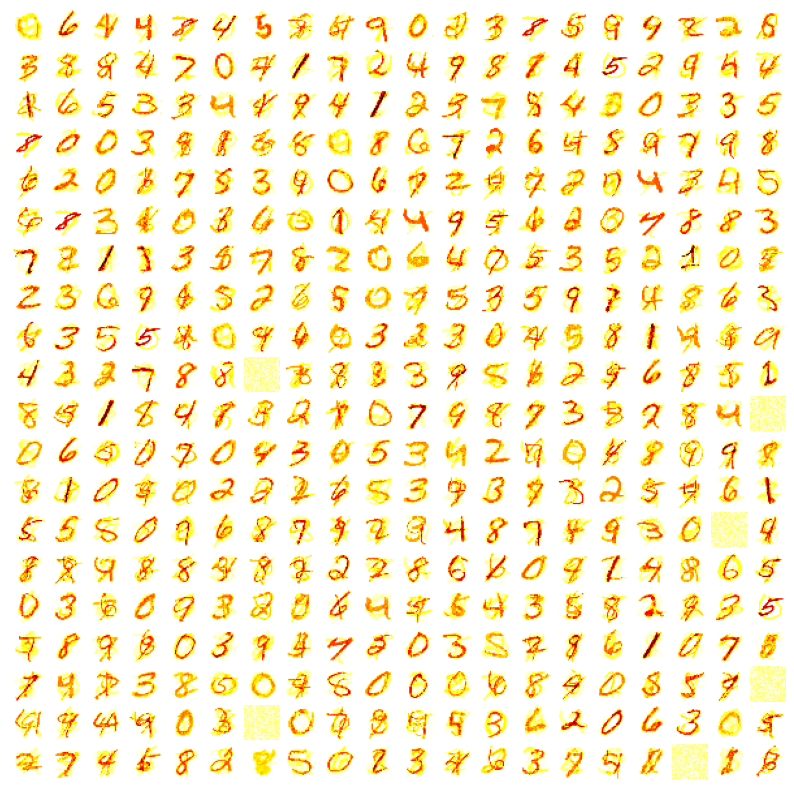

In [7]:
final_weights = get_2d_weights(net['s_inp_exc'], n_input, n_e)
plot_weights(final_weights, n_e)

In [10]:
# saving the trained model weights

save_path = '../trained_model/garg/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

trained_weights = np.array(net['s_inp_exc'].w)
np.save(os.path.join(save_path, 'weights.npy'), trained_weights)

trained_theta = np.array(net['exc'].theta)
np.save(os.path.join(save_path, 'thetas.npy'), trained_theta)